# Stage 2: Expected Revenue + Combined CLV

Estimates **expected revenue per buyer** using spend-tier averages, then combines with Stage 1 purchase probability.

**Why not individual regression?** Individual-level revenue prediction is typically noisy -- the features that predict *who* buys do not necessarily predict *how much* they spend. Instead, we use historical spend tiers as a natural revenue proxy: customers with higher `monetary_value` in the calibration period tend to spend more in the holdout.

- **Input:** `data/processed/stage1_scored.csv` (4,918 customers with `p_purchase` from Stage 1)
- **Approach:** Bin customers by `monetary_value` into spend terciles, compute tier-level average holdout revenue for buyers
- **Combined CLV:** `clv_180d = p_purchase x expected_revenue_if_purchase`

**Outputs:**
- `data/processed/clv_scored.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Load Stage 1 Output

In [2]:
df = pd.read_csv('../data/processed/stage1_scored.csv')
print(f"Loaded {len(df):,} customers")
print(f"p_purchase range: [{df['p_purchase'].min():.4f}, {df['p_purchase'].max():.4f}]")
print(f"p_purchase mean:  {df['p_purchase'].mean():.4f}")

# Holdout buyers
buyers = df[df['actual_holdout_transactions'] > 0].copy()
non_buyers = df[df['actual_holdout_transactions'] == 0].copy()
print(f"\nHoldout buyers:     {len(buyers):,} ({len(buyers)/len(df):.1%})")
print(f"Holdout non-buyers: {len(non_buyers):,} ({len(non_buyers)/len(df):.1%})")
print(f"\nHoldout period: 2011-06-09 to 2011-12-09 (~183 days)")

Loaded 4,918 customers
p_purchase range: [0.0000, 0.9926]
p_purchase mean:  0.5148

Holdout buyers:     2,557 (52.0%)
Holdout non-buyers: 2,361 (48.0%)

Holdout period: 2011-06-09 to 2011-12-09 (~183 days)


## 2. Spend Tier Construction

Bin all customers by `monetary_value` (historical avg order value on repeat transactions) into terciles. Then compute the actual average holdout revenue per buyer within each tier.

In [3]:
# Create spend tiers using terciles of monetary_value (all customers)
df['spend_tier'] = pd.qcut(
    df['monetary_value'], q=3,
    labels=['Low Spend', 'Mid Spend', 'High Spend']
)

print("Spend tier thresholds (monetary_value):")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    tier_data = df[df['spend_tier'] == tier]['monetary_value']
    print(f"  {tier}: ${tier_data.min():.2f} -- ${tier_data.max():.2f} ({len(tier_data):,} customers)")

Spend tier thresholds (monetary_value):
  Low Spend: $1.25 -- $194.75 (1,639 customers)
  Mid Spend: $194.80 -- $342.01 (1,640 customers)
  High Spend: $342.14 -- $14686.70 (1,639 customers)


In [4]:
# Compute average holdout revenue PER BUYER within each tier
buyers_with_tier = df[df['actual_holdout_transactions'] > 0].copy()

tier_revenue = buyers_with_tier.groupby('spend_tier').agg(
    n_buyers           = ('user_id', 'count'),
    avg_holdout_rev    = ('actual_holdout_revenue', 'mean'),
    median_holdout_rev = ('actual_holdout_revenue', 'median'),
    total_holdout_rev  = ('actual_holdout_revenue', 'sum'),
).round(2)

print("=== Tier-Level Revenue (holdout buyers only) ===")
print(tier_revenue.to_string())
print(f"\nOverall avg holdout revenue per buyer: ${buyers_with_tier['actual_holdout_revenue'].mean():.2f}")

=== Tier-Level Revenue (holdout buyers only) ===
            n_buyers  avg_holdout_rev  median_holdout_rev  total_holdout_rev
spend_tier                                                                  
Low Spend        629           527.21              300.85          331612.59
Mid Spend        918           939.73              549.12          862667.62
High Spend      1010          3138.32             1188.47         3169707.86

Overall avg holdout revenue per buyer: $1706.68


In [5]:
# KEY CHECK: Do spend tiers produce meaningful revenue differentiation?
tier_avgs = tier_revenue['avg_holdout_rev']
tier_range = tier_avgs.max() - tier_avgs.min()
tier_cv = tier_avgs.std() / tier_avgs.mean() if tier_avgs.mean() > 0 else 0

print("=== Tier Differentiation Check ===")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    print(f"  {tier}: ${tier_avgs[tier]:.2f} avg holdout revenue per buyer")
print(f"\n  Range: ${tier_range:.2f}")
print(f"  CV (coefficient of variation): {tier_cv:.3f}")

if tier_cv < 0.05:
    print("\n  ** Tier averages are nearly flat (CV < 5%). **")
    print("  This means monetary_value does NOT strongly predict holdout spend.")
    print("  CLV differentiation will come primarily from P(purchase), not E[revenue].")
    print("  The tier approach still works -- it just means CLV ~ p_purchase x constant.")
else:
    print(f"\n  Tiers show meaningful differentiation (CV = {tier_cv:.1%}).")
    print("  Higher historical spenders do spend more in holdout -- tiers add signal.")

=== Tier Differentiation Check ===
  Low Spend: $527.21 avg holdout revenue per buyer
  Mid Spend: $939.73 avg holdout revenue per buyer
  High Spend: $3138.32 avg holdout revenue per buyer

  Range: $2611.11
  CV (coefficient of variation): 0.914

  Tiers show meaningful differentiation (CV = 91.4%).
  Higher historical spenders do spend more in holdout -- tiers add signal.


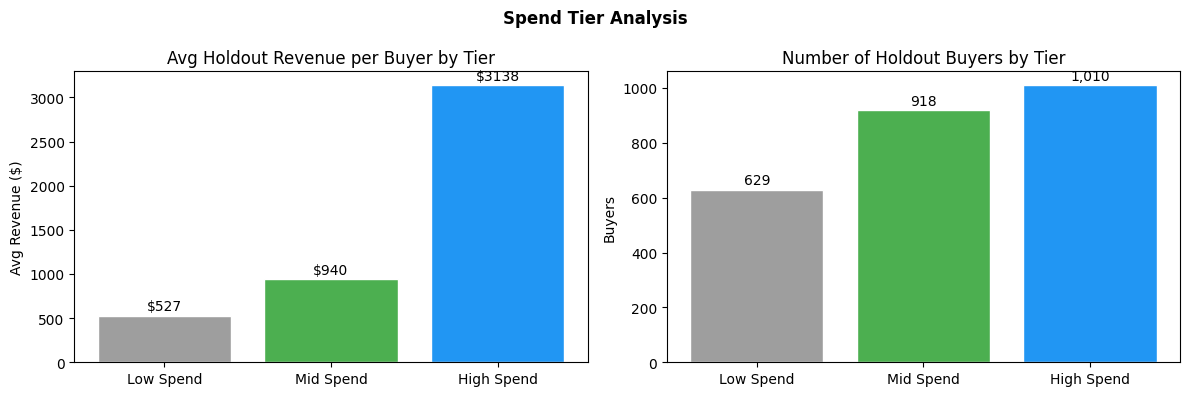

In [6]:
# Visualize revenue by tier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#9E9E9E', '#4CAF50', '#2196F3']
tiers = ['Low Spend', 'Mid Spend', 'High Spend']

# Average revenue per buyer by tier
avg_revs = [tier_revenue.loc[t, 'avg_holdout_rev'] for t in tiers]
axes[0].bar(tiers, avg_revs, color=colors, edgecolor='white')
axes[0].set_title('Avg Holdout Revenue per Buyer by Tier')
axes[0].set_ylabel('Avg Revenue ($)')
for i, v in enumerate(avg_revs):
    axes[0].text(i, v + max(avg_revs) * 0.02, f'${v:.0f}', ha='center', fontsize=10)

# Number of buyers per tier
n_buyers_list = [tier_revenue.loc[t, 'n_buyers'] for t in tiers]
axes[1].bar(tiers, n_buyers_list, color=colors, edgecolor='white')
axes[1].set_title('Number of Holdout Buyers by Tier')
axes[1].set_ylabel('Buyers')
for i, v in enumerate(n_buyers_list):
    axes[1].text(i, v + max(n_buyers_list) * 0.02, f'{int(v):,}', ha='center', fontsize=10)

plt.suptitle('Spend Tier Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Map Expected Revenue to All Customers

In [7]:
# Create tier -> expected revenue mapping
tier_avg_map = tier_revenue['avg_holdout_rev'].to_dict()
print("Tier -> Expected Revenue mapping:")
for tier, rev in tier_avg_map.items():
    print(f"  {tier}: ${rev:.2f}")

# Map to all customers
df['expected_revenue_if_purchase'] = df['spend_tier'].map(tier_avg_map)

print(f"\nMapped to all {len(df):,} customers")
print(f"Null values: {df['expected_revenue_if_purchase'].isna().sum()}")

Tier -> Expected Revenue mapping:
  Low Spend: $527.21
  Mid Spend: $939.73
  High Spend: $3138.32

Mapped to all 4,918 customers
Null values: 0


## 4. Combined CLV

The holdout window runs from 2011-06-09 to 2011-12-09, which is **183 days**.

- `clv_180d = p_purchase x expected_revenue_if_purchase` (holdout-period CLV)
- `clv_12m = clv_180d x (365 / 183)` (annualized estimate via linear extrapolation)

In [8]:
HOLDOUT_DAYS = 183  # 2011-06-09 to 2011-12-09

# CLV = P(purchase) x E[revenue | purchase]
df['expected_revenue_if_purchase'] = pd.to_numeric(
    df['expected_revenue_if_purchase'], errors='coerce'
)
df['clv_180d'] = df['p_purchase'] * df['expected_revenue_if_purchase']

# Scale to 12-month estimate using actual holdout length
df['clv_12m'] = df['clv_180d'] * (365 / HOLDOUT_DAYS)

print("=== Combined CLV Distribution ===")
print(f"CLV (180d): ${df['clv_180d'].mean():.2f} avg, ${df['clv_180d'].median():.2f} median")
print(f"CLV (12m):  ${df['clv_12m'].mean():.2f} avg, ${df['clv_12m'].median():.2f} median")
print(f"\nComponents:")
print(f"  P(purchase):     {df['p_purchase'].mean():.4f} avg")
print(f"  E[rev|purchase]: ${df['expected_revenue_if_purchase'].mean():.2f} avg")

print(f"\nCLV (180d) percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p}: ${df['clv_180d'].quantile(p/100):.2f}")

=== Combined CLV Distribution ===
CLV (180d): $888.47 avg, $477.16 median
CLV (12m):  $1772.09 avg, $951.72 median

Components:
  P(purchase):     0.5148 avg
  E[rev|purchase]: $1534.97 avg

CLV (180d) percentiles:
  P10: $78.38
  P25: $201.06
  P50: $477.16
  P75: $1009.01
  P90: $2846.08
  P95: $3054.69
  P99: $3115.07


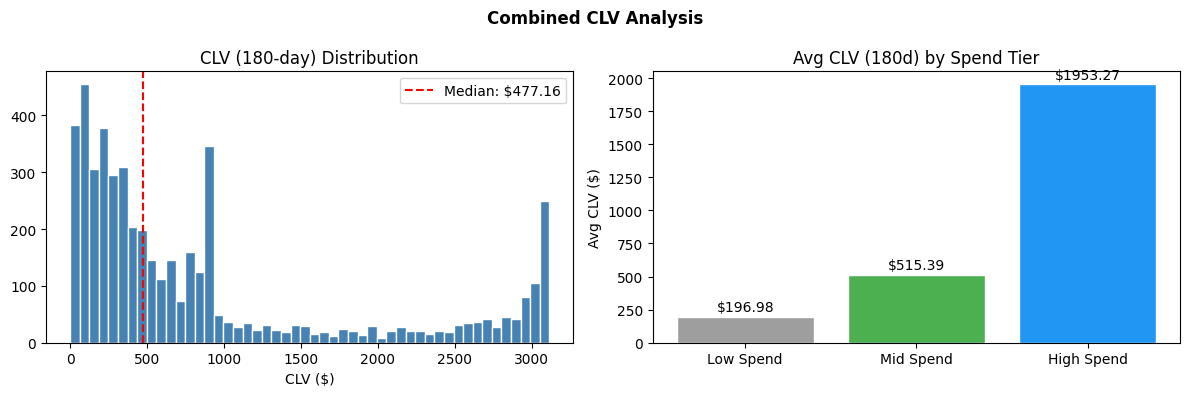

In [9]:
# CLV distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['clv_180d'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('CLV (180-day) Distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].axvline(
    df['clv_180d'].median(), color='red', linestyle='--',
    label=f"Median: ${df['clv_180d'].median():.2f}"
)
axes[0].legend()

# CLV by spend tier
tier_clv = df.groupby('spend_tier')['clv_180d'].mean()
axes[1].bar(tiers, [tier_clv[t] for t in tiers], color=colors, edgecolor='white')
axes[1].set_title('Avg CLV (180d) by Spend Tier')
axes[1].set_ylabel('Avg CLV ($)')
for i, t in enumerate(tiers):
    axes[1].text(i, tier_clv[t] + tier_clv.max() * 0.02,
                f'${tier_clv[t]:.2f}', ha='center', fontsize=10)

plt.suptitle('Combined CLV Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Sanity Checks

In [10]:
# Check 1: One-time buyers should have lower CLV than repeat buyers
clv_onetime = df.loc[df['frequency'] == 0, 'clv_180d'].mean()
clv_repeat  = df.loc[df['frequency'] >= 1, 'clv_180d'].mean()
print(f"One-time buyer avg CLV (180d): ${clv_onetime:.2f}")
print(f"Repeat buyer avg CLV (180d):   ${clv_repeat:.2f}")
print(f"Check: one-time < repeat: {'PASS' if clv_onetime < clv_repeat else 'FAIL'}")

# Check 2: Top 20% should capture disproportionate share of predicted CLV
top20_n = int(len(df) * 0.2)
top20_clv = df.nlargest(top20_n, 'clv_180d')['clv_180d'].sum()
total_clv = df['clv_180d'].sum()
top20_pct = top20_clv / total_clv
print(f"\nTop 20% customers account for {top20_pct:.1%} of total predicted CLV")

# Check 3: Total predicted vs actual holdout revenue
total_pred = df['clv_180d'].sum()
total_actual = df['actual_holdout_revenue'].sum()
print(f"\nTotal predicted (180d): ${total_pred:,.0f}")
print(f"Total actual (holdout): ${total_actual:,.0f}")
print(f"Ratio: {total_pred / total_actual:.2f}")

One-time buyer avg CLV (180d): $412.25
Repeat buyer avg CLV (180d):   $1103.12
Check: one-time < repeat: PASS

Top 20% customers account for 59.9% of total predicted CLV

Total predicted (180d): $4,369,500
Total actual (holdout): $4,363,988
Ratio: 1.00


## 6. Save Outputs

In [11]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/clv_scored.csv', index=False)

print(f"Scored data saved to data/processed/clv_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"  Key columns: p_purchase, spend_tier, expected_revenue_if_purchase, clv_180d, clv_12m")
print(f"\n  New columns added:")
print(f"    spend_tier                  — Low/Mid/High Spend (monetary_value tercile)")
print(f"    expected_revenue_if_purchase — tier avg holdout revenue for buyers")
print(f"    clv_180d                    — p_purchase x expected_revenue_if_purchase")
print(f"    clv_12m                     — clv_180d x (365 / {HOLDOUT_DAYS})")

Scored data saved to data/processed/clv_scored.csv
  Shape: 4,918 x 25
  Key columns: p_purchase, spend_tier, expected_revenue_if_purchase, clv_180d, clv_12m

  New columns added:
    spend_tier                  — Low/Mid/High Spend (monetary_value tercile)
    expected_revenue_if_purchase — tier avg holdout revenue for buyers
    clv_180d                    — p_purchase x expected_revenue_if_purchase
    clv_12m                     — clv_180d x (365 / 183)


In [12]:
print("=" * 55)
print("STAGE 2 SUMMARY: Expected Revenue + Combined CLV")
print("=" * 55)
print(f"Dataset:                 UCI Online Retail II")
print(f"Customers:               {len(df):,}")
print(f"Holdout window:          183 days (2011-06-09 to 2011-12-09)")
print(f"Approach:                Spend-tier avg revenue")
print(f"Tiers:                   {', '.join(tiers)}")
print(f"Tier revenue range:      ${tier_revenue['avg_holdout_rev'].min():.2f} -- ${tier_revenue['avg_holdout_rev'].max():.2f}")
print(f"Mean CLV (180d):         ${df['clv_180d'].mean():.2f}")
print(f"Mean CLV (12m):          ${df['clv_12m'].mean():.2f}")
print(f"Total predicted (180d):  ${df['clv_180d'].sum():,.0f}")
print(f"Total actual (holdout):  ${df['actual_holdout_revenue'].sum():,.0f}")
print(f"Calibration ratio:       {df['clv_180d'].sum() / df['actual_holdout_revenue'].sum():.3f}")
print("=" * 55)
print("\nNext: 04_clv_validation.ipynb")

STAGE 2 SUMMARY: Expected Revenue + Combined CLV
Dataset:                 UCI Online Retail II
Customers:               4,918
Holdout window:          183 days (2011-06-09 to 2011-12-09)
Approach:                Spend-tier avg revenue
Tiers:                   Low Spend, Mid Spend, High Spend
Tier revenue range:      $527.21 -- $3138.32
Mean CLV (180d):         $888.47
Mean CLV (12m):          $1772.09
Total predicted (180d):  $4,369,500
Total actual (holdout):  $4,363,988
Calibration ratio:       1.001

Next: 04_clv_validation.ipynb
